# Compare Learning Models of Behavior
This program fits and computes weighted (negLL) and unweighted (BIC) fit metrics for the following models:
- RPE (Rescorla-Wagner)
- mRPE- the Hjort et al. 2026 model where averaged positive (CE) and negative (CD) RPEs modulate learning rate via meta-RPE
- RPEt-1- a variant of the RPE model where learning rate is modulated by the RPE on the previous trial 
- RPE2a- a variant of the RPE model with split learning rates for positive and negative RPEs
- PH- the Pearce-Hall salience model as written in Le Pelley 2004
- eMack- the enhanced Mackintosh model as written in Le Pelley 2004

The fitting mechanisms are adapted from https://doi.org/10.21105/jose.00146, specifically, https://shawnrhoads.github.io/gu-psyc-347/module-03-01_Models-of-Learning.html

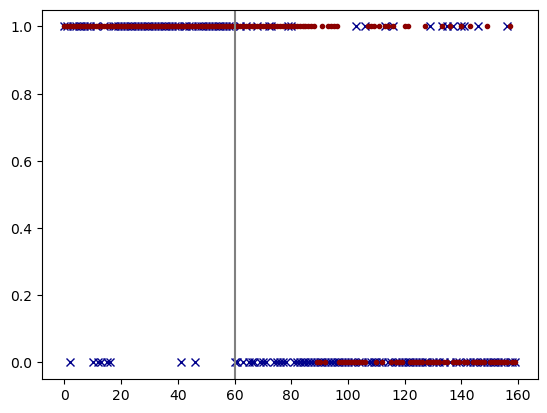

In [1]:
# Load the data
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize 
from scipy import stats             
import math
import statsmodels.api as sm

# source directory of the data
# change this to wherever you stored the source data
fdir=r'C:\Users\nsciebner\Desktop\PFC Revision\Fig 1- model\Processed Data for Upload\A1'
os.chdir(fdir)

#Load the animal data (this is concatenated across 4 days)
o1_choice=np.load('HL_choice.npy')
o1_rew=np.load('HL_outcome.npy')

# plot the choice (red dot) and reward outcome (blue X)
#pre=0-40, rev1=40-80 (contingency switch at 60), rev2=80-120, post=120-160
plt.plot(o1_rew, 'x', color='darkblue')
plt.plot(o1_choice, '.', color='darkred')
plt.axvline(60,color='gray')

# Run the meta-RPE model
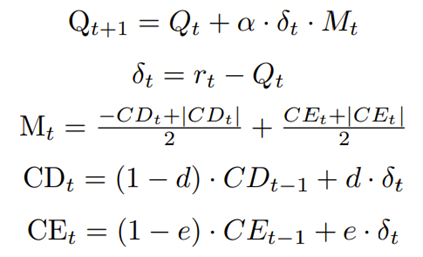

In [2]:
def rw_M(params, c, r, Q):
    alpha, beta, m, n = params
    if Q==15:
        Q = [0.85,0.15] 
    elif Q==85:
        Q = [0.15,0.85]
    T = len(c)
    M= np.zeros(len(c))
    Md= np.zeros(len(c))
    Me= np.zeros(len(c))
    M= np.zeros(len(c))
    choiceProb = np.zeros((T), dtype = float)

    for t in range(T):
        p0 = np.exp(beta*Q[0]) / (np.exp(beta*Q[0]) + np.exp(beta*Q[1]))
        p = [p0, 1-p0]
        

        # compute choice probability 
        choiceProb[t] = p[c[t]]

        # update values
        delta = r[t] - Q[c[t]]
        Md[t]= (1-m)*Md[t-1]+m*(delta)
        Me[t]= (1-n)*Me[t-1]+n*(delta)
        M[t]=((-Md[t]+np.abs(Md[t]))/2 +(Me[t]+np.abs(Me[t]))/2)
        Q[c[t]] = Q[c[t]] + alpha * delta * abs(M[t])
        
    negLL = -np.sum(np.log(choiceProb))
    
    return negLL

In [3]:
def rw_sM( params, c, r, Q):
    if Q==15:
        Q = [0.85,0.15]  
    elif Q==85:
        Q = [0.15,0.85]
    
    alpha, beta, m, n = params
    T=c.shape[0]
    Md= np.zeros(len(c))
    Me= np.zeros(len(c)) 
    M= np.zeros(len(c))
    Q_stored = np.zeros((2, T), dtype = float)
    D_stored = np.zeros((2, T), dtype = float)
    Md_stored = np.zeros((2, T), dtype = float)
    Me_stored = np.zeros((2, T), dtype = float)
    M_stored = np.zeros((2, T), dtype = float)

    for t in range(T):
        Q_stored[:,t] = Q
        delta = r[t] - Q[c[t]]
        Md[t]= (1-m)*Md[t-1]+m*(delta)
        Me[t]= (1-n)*Me[t-1]+n*(delta)
        M[t]=((-Md[t]+np.abs(Md[t]))/2 +(Me[t]+np.abs(Me[t]))/2)
        Q[c[t]] = Q[c[t]] + alpha * delta * abs(M[t])
        D_stored[:,t] = delta
        Md_stored[:,t] = Md[t]
        Me_stored[:,t] = Me[t]
        M_stored[:,t] = M[t]
        
    return Q_stored, D_stored, Md_stored,Me_stored, M_stored



In [4]:
def M_RW( params, c, r, Q):
    if Q==15:
        Q = [0.85,0.15]  # second spot is lick choice
    elif Q==85:
        Q = [0.15,0.85]
    
    alpha, beta, m, n = params
    T=c.shape[0]
    Md= np.zeros(len(c))
    Me= np.zeros(len(c)) 
    M= np.zeros(len(c))
    Q_stored = np.zeros((2, T), dtype = float)
    D_stored = np.zeros((2, T), dtype = float)
    Md_stored = np.zeros((2, T), dtype = float)
    Me_stored = np.zeros((2, T), dtype = float)
    M_stored = np.zeros((2, T), dtype = float)

    for t in range(T):
        Q_stored[:,t] = Q
        delta = r[t] - Q[c[t]]
        Md[t]= (1-m)*Md[t-1]+m*(delta)
        Me[t]= (1-n)*Me[t-1]+n*(delta)
        M[t]=(-Md[t]+np.abs(Md[t]))/2 +(Me[t]+np.abs(Me[t]))/2
        Q[c[t]] = Q[c[t]] + alpha * delta * abs(M[t])
        D_stored[:,t] = delta
        Md_stored[:,t] = Md[t]
        Me_stored[:,t] = Me[t]
        M_stored[:,t] = M[t]
        
    return Q_stored[1:].T, D_stored[1:].T, Md_stored[1:].T,Me_stored[1:].T, M_stored[1:].T



In [5]:
def fit_rwM(c,r,Q):
# gradient descent to minimize neg LL
    import warnings
    warnings.filterwarnings("ignore")

    res_nll = np.inf 

    # initialize the function starting points
    for alpha_guess in np.linspace(0,1,2):
        for beta_guess in np.linspace(1,5,2):
            for m_guess in np.linspace(0.01,0.1,3):
                 for n_guess in np.linspace(0.01,0.1,3):
                    init_guess = (alpha_guess, beta_guess, m_guess, n_guess)

                    # fit the function
                    result = minimize(rw_M, 
                                      init_guess, 
                                      (c, r, Q), 
                                      bounds=((0.01,10),(1,10),(0.01,0.1),(0.01,0.1)))

                    # store the result if it fit better than previous runs
                    if result.fun < res_nll:
                        
                        res_nll = result.fun
                        param_fits = result.x

    # compute BIC
    BIC = len(init_guess) * np.log(len(c)) + 2*res_nll

    # package parameters and results for return
    beta_hat= param_fits[1]
    params1=[param_fits[0],param_fits[1],param_fits[2],param_fits[3]]
    Q,D, Md, Me, M=rw_sM(params1,c,r,Q)
    Q1=Q[1,:]
    D1=D[1,:]
    Md1=Md[1,:]
    Me1=Me[1,:]
    M1=M[1,:]
    return param_fits[0], param_fits[1], param_fits[2],param_fits[3],Q1, D1, BIC,Md1,Me1, M1, res_nll

Text(0, 0.5, 'Value')

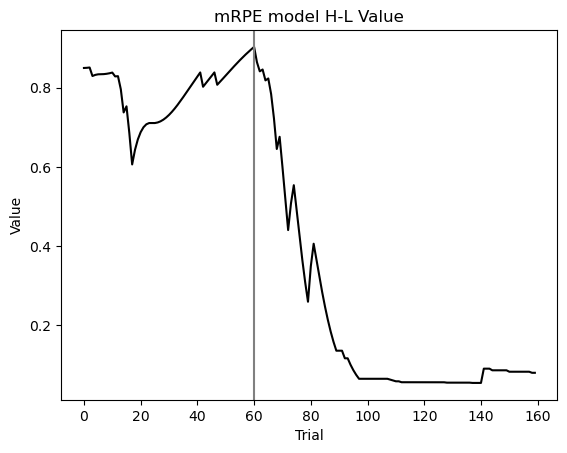

In [6]:
#fit the model
c=o1_choice # animal choice behavior
r=o1_rew # reward history 
    
a1, b1,m1,n1,Q1M, D1M, BIC1M, Md1, Me1,M1, negLLM=fit_rwM(c,r,85)
# a1=alpha, b1=beta, m1=mRPE- integration, n1= mRPE+ integration
#Q1M=value, D1M=RPE, BIC1M= bic from this model 
#for plotting stuff, Md1=mRPE-, Me1=mRPE+, M1=mRPE
plt.plot(Q1M, color='k')
plt.axvline(60, color='gray')
plt.title('mRPE model H-L Value')
plt.xlabel('Trial')
plt.ylabel('Value')

# Run the Rescorla-Wagner RPE model
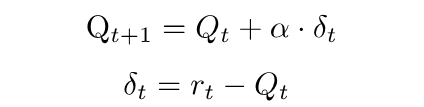

In [7]:
# the RW model for fitting H-L
def rw_85(params, c, r):
    alpha, beta = params
    
    Q = [0.15,0.85]  
    T = len(c)
    choiceProb = np.zeros((T), dtype = float)

    for t in range(T):
        p0 = np.exp(beta*Q[0]) / (np.exp(beta*Q[0]) + np.exp(beta*Q[1]))
        p = [p0, 1-p0]
        choiceProb[t] = p[c[t]]
        delta = r[t] - Q[c[t]]
        Q[c[t]] = Q[c[t]] + alpha * delta 
        
    negLL = -np.sum(np.log(choiceProb))
    
    return negLL

In [8]:
# the function that fits H-L RW
def fit_rw85(c,r):
    import warnings
    warnings.filterwarnings("ignore")
    res_nll = np.inf 
    for alpha_guess in np.linspace(0,1,3):
        for beta_guess in np.linspace(1,5,3):
            init_guess = (alpha_guess, beta_guess)
            result = minimize(rw_85, 
                              init_guess, 
                              (c, r), 
                              bounds=((0.01,1),(0,50)))
            if result.fun < res_nll:
                res_nll = result.fun
                param_fits = result.x


    BIC = len(init_guess) * np.log(len(c)) + 2*res_nll

    beta_hat= param_fits[1]
    params1=[param_fits[0],param_fits[1]]
    Q,D=rw_85s(params1,c,r)
    Q1=Q[1,:]
    D1=D[1,:]

    return param_fits[0], param_fits[1], Q1, D1, BIC, res_nll

In [9]:
# the function that runs the simulated H-L
def rw_85s(params, c, r):

    alpha, beta = params
    T=c.shape[0]
         
    Q_stored = np.zeros((2, T), dtype = float)
    D_stored = np.zeros((2, T), dtype = float)
    Q = [0.15,0.85] 

    for t in range(T):
        Q_stored[:,t] = Q
        delta = r[t] - Q[c[t]]
        Q[c[t]] = Q[c[t]] + alpha * delta 
        D_stored[:,t] = delta
        
    return Q_stored, D_stored



H-L


Text(0.5, 1.0, 'RW Model H-L Value')

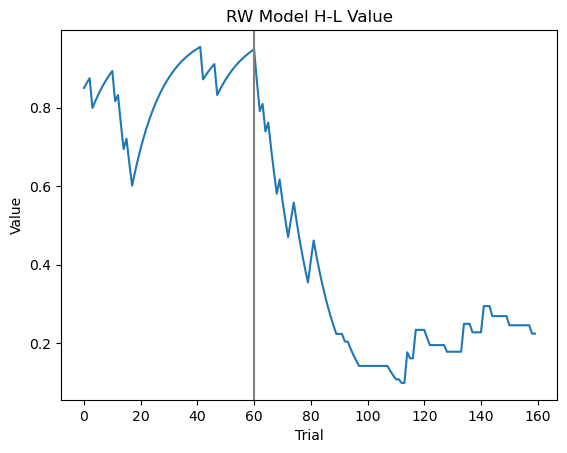

In [10]:
print('H-L')
c=o1_choice 
r=o1_rew
  
a1, b1, Q1, D1, BIC, negLL=fit_rw85(c,r) 
# a1=alpha, b1=beta, Q1=RW value, D1=RW RPE, BIC=BIC
plt.plot(Q1)
plt.axvline(60, color='gray')
plt.xlabel('Trial')
plt.ylabel('Value')
plt.title('RW Model H-L Value')

# Run the RPE2a model
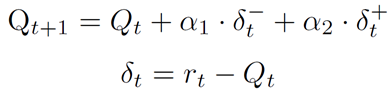


In [11]:
# the RW model for fitting H-L

def rw_2a(params, c, r):
    alpha1, alpha2, beta = params
    
    Q = [0.15,0.85]   
    T = len(c)
    choiceProb = np.zeros((T), dtype = float)

    for t in range(T):
        p0 = np.exp(beta*Q[0]) / (np.exp(beta*Q[0]) + np.exp(beta*Q[1]))
        p = [p0, 1-p0]
        choiceProb[t] = p[c[t]]
        delta = r[t] - Q[c[t]]
        if delta<=0: # negative RPEs
            Q[c[t]] = Q[c[t]] + alpha1 * delta 
        if delta>0: # positive RPEs
            Q[c[t]] = Q[c[t]] + alpha2 * delta 
                
        
    negLL = -np.sum(np.log(choiceProb))
    
    return negLL

In [12]:

def fit_rw2a(c,r):
    import warnings
    warnings.filterwarnings("ignore")
    res_nll = np.inf 
    for alpha1_guess in np.linspace(0,1,3):
        for alpha2_guess in np.linspace(0,1,3):
            for beta_guess in np.linspace(1,5,3):
                init_guess = (alpha1_guess,alpha2_guess, beta_guess)
                result = minimize(rw_2a, 
                                  init_guess, 
                                  (c, r), 
                                  bounds=((0.01,1),(0.01,1),(0,10)))
                if result.fun < res_nll:
                    res_nll = result.fun
                    param_fits = result.x

    BIC = len(init_guess) * np.log(len(c)) + 2*res_nll
    
    params1=[param_fits[0],param_fits[1],param_fits[2]]
    Q,D=rw_2as(params1,c,r)
    Q1=Q[1,:]
    D1=D[1,:]

    return param_fits[0], param_fits[1],param_fits[2], Q1, D1, BIC, res_nll

In [13]:
def rw_2as(params, c, r):

    alpha1, alpha2, beta = params
    T=c.shape[0]
         
    Q_stored = np.zeros((2, T), dtype = float)
    D_stored = np.zeros((2, T), dtype = float)
    Q = [0.15,0.85] 

    for t in range(T):
        Q_stored[:,t] = Q
        delta = r[t] - Q[c[t]]
        if delta <0:
            Q[c[t]] = Q[c[t]] + alpha1 * delta 
        if delta >0:
            Q[c[t]] = Q[c[t]] + alpha2 * delta 
        D_stored[:,t] = delta
        
    return Q_stored, D_stored



H-L


Text(0.5, 1.0, 'Two alpha RW Model H-L Value')

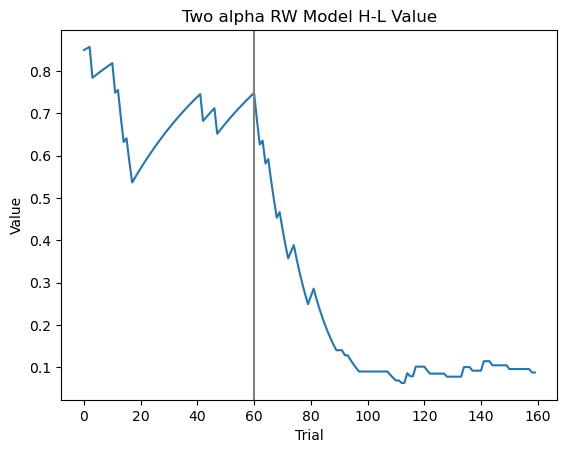

In [14]:
print('H-L')
c=o1_choice 
r=o1_rew
  
a12a, a22a, b12a, Q12a, D12a, BIC2a, negLL2a=fit_rw2a(c,r) 
# a1=alpha, b1=beta, Q1=RW value, D1=RW RPE, BIC=BIC
plt.plot(Q12a)
plt.axvline(60, color='gray')
plt.xlabel('Trial')
plt.ylabel('Value')
plt.title('Two alpha RW Model H-L Value')

# Run the RPE t-1 model
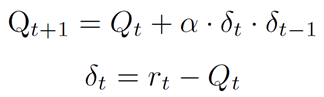

In [15]:
def rw_T(params, c, r):
    alpha, beta = params
    
    Q = [0.15,0.85]  
    T = len(c)
    choiceProb = np.zeros((T), dtype = float)
    delta_t_minus1=0
    for t in range(T):
        p0 = np.exp(beta*Q[0]) / (np.exp(beta*Q[0]) + np.exp(beta*Q[1]))
        p = [p0, 1-p0]
        choiceProb[t] = p[c[t]]
        delta = r[t] - Q[c[t]]
        Q[c[t]] = Q[c[t]] + alpha * delta * delta_t_minus1 
        delta_t_minus1=np.abs(delta) # the RPE from this trial, which will be previous trial for next trial
        
    negLL = -np.sum(np.log(choiceProb))
    
    return negLL

In [16]:
def fit_rwT(c,r):
    import warnings
    warnings.filterwarnings("ignore")
    res_nll = np.inf 
    for alpha_guess in np.linspace(0,1,3):
        for beta_guess in np.linspace(1,5,3):
            init_guess = (alpha_guess, beta_guess)
            result = minimize(rw_T, 
                              init_guess, 
                              (c, r), 
                              bounds=((0.01,0.5),(0,50)))
            if result.fun < res_nll:
                res_nll = result.fun
                param_fits = result.x
    BIC = len(init_guess) * np.log(len(c)) + 2*res_nll
    beta_hat= param_fits[1]
    params1=[param_fits[0],param_fits[1]]
    Q,D=rw_Ts(params1,c,r)
    Q1=Q[1,:]
    D1=D[1,:]

    return param_fits[0], param_fits[1], Q1, D1, BIC, res_nll

In [17]:
def rw_Ts(params, c, r):

    alpha, beta = params
    T=c.shape[0]
    delta_t_minus1=0     
    Q_stored = np.zeros((2, T), dtype = float)
    D_stored = np.zeros((2, T), dtype = float)
    Q = [0.15,0.85] 

    for t in range(T):
        Q_stored[:,t] = Q
        delta = r[t] - Q[c[t]]
        Q[c[t]] = Q[c[t]] + alpha * delta * delta_t_minus1
        D_stored[:,t] = delta
        delta_t_minus1=np.abs(delta)
        
    return Q_stored, D_stored



H-L


Text(0.5, 1.0, 'RW Model RPE t-1 H-L Value')

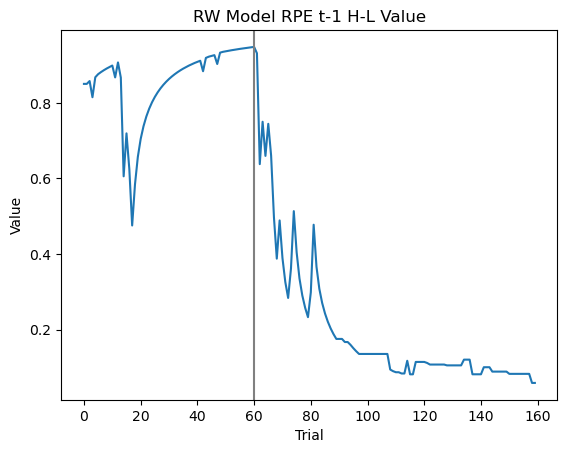

In [18]:
print('H-L')
c=o1_choice 
r=o1_rew
  
a1t, b1t, Q1t, D1t, BICt, negLLt=fit_rwT(c,r) 
# a1=alpha, b1=beta, Q1=RW value, D1=RW RPE, BIC=BIC
plt.plot(Q1t)
plt.axvline(60, color='gray')
plt.xlabel('Trial')
plt.ylabel('Value')
plt.title('RW Model RPE t-1 H-L Value')

# Run the Pearce-Hall Model
As described in LePelley et al 2004: https://psycnet.apa.org/record/2004-15295-001

In [19]:
 def PH_s(params, c, r, Q):

            # initialize variables 
            Be, Bi,gamma, beta=params 
            Vy=np.zeros((c.shape[0]+1)) # value of CS-Rew 
            Vn=np.zeros((c.shape[0]+1)) # value of CS-NR 
            Vnet=np.zeros((c.shape[0]+1))
            alpha=np.zeros((c.shape[0]+1)) # learning rate (variable) 
            Rs=np.zeros((c.shape[0]+1))

            if Q==15: 
                Vy[0]=0.15 
                Vn[0]=0.85 
            elif Q==85: 
                Vy[0]=0.85 
                Vn[0]=0.15 
    
            alpha[0]=0.05
            T=c.shape[0] 
    
            for t in range(T): 
                # calculate V for trial t 
                Vnet[t]=Vy[t]-Vn[t]
                # calculate R \"effective strength of reinforcer\" 
                R=r[t]-(Vy[t]-Vn[t])
    
                # update Vy and Vn 
                if R>0: 
                    dVy=alpha[t]*Be*r[t]
                    dVn=0 
                elif R<0: 
                    dVn=alpha[t]*Bi*np.abs(R) 
                    dVy=0 
                else: 
                    dVy=0 
                    dVn=0 
    
                # update alpha (variable learning rate) 
                alpha[t+1]=gamma*abs(r[t]-Vnet[t])+(1-gamma)*alpha[t]
  
                # update for next trial 
                Vy[t+1]=Vy[t]+dVy
                Vn[t+1]=Vn[t]+dVn
                if Vy[t+1]>1:
                    Vy[t+1]=1
                if Vn[t+1]<0:
                    Vn[t+1]=0

                Rs[t]=R

            return Vnet[0:160], Rs

In [20]:

def PH(params, c, r,Q):

    Be, Bi,gamma, beta=params
    Vy=np.zeros((c.shape[0]+1)) # value of CS-Rew 
    Vn=np.zeros((c.shape[0]+1)) # value of CS-NR 
    Vnet=np.zeros((c.shape[0]+1))
    alpha=np.zeros((c.shape[0]+1)) # learning rate (variable) 
    Rs=np.zeros((c.shape[0]+1))
    if Q==15: 
        Vy[0]=0.15 
        Vn[0]=0.85 
        Q = [0.85,0.15]
    elif Q==85: 
        Vy[0]=0.85 
        Vn[0]=0.15 
        Q = [0.15,0.85]  # second spot is win probability 
  
    alpha[0]=0.05
    T=c.shape[0] 
    choiceProb = np.zeros((T), dtype = float)

    for t in range(T):
        p0 = np.exp(beta*Q[0]) / (np.exp(beta*Q[0]) + np.exp(beta*Q[1]))
        p = [p0, 1-p0]
        choiceProb[t] = p[c[t]]

        # update values
        
         # calculate V for trial t 
       # calculate V for trial t 
        Vnet[t]=Vy[t]-Vn[t]
                # calculate R \"effective strength of reinforcer\" 
        R=r[t]-(Vy[t]-Vn[t])
    
         # update Vy and Vn 
        if R>0: 
            dVy=alpha[t]*Be*r[t]
            dVn=0 
        elif R<0: 
            dVn=alpha[t]*Bi*np.abs(R) 
            dVy=0 
        else: 
            dVy=0 
            dVn=0 
    
                # update alpha (variable learning rate) 
        alpha[t+1]=gamma*abs(r[t]-Vnet[t])+(1-gamma)*alpha[t]
  
        # update for next trial 
        Vy[t+1]=Vy[t]+dVy
        Vn[t+1]=Vn[t]+dVn
        
        if Vy[t+1]>1:
            Vy[t+1]=1
        if Vn[t+1]<0:
            Vn[t+1]=0
            
        Q[0]=Vn[t+1]
        Q[1]=Vy[t+1]

                
        Rs[t]=R
        
           
    negLL = -np.sum(np.log(choiceProb))
    
    return negLL

In [21]:
def fit_PH(c,r,Q):
# gradient descent to minimize neg LL
    import warnings
    warnings.filterwarnings("ignore")

    res_nll = np.inf 
    for gamma_guess in np.linspace(0.05,0.9,5):
        for Be_guess in np.linspace(0.05,0.9,3):
            for Bi_guess in np.linspace(0.05,0.9,3):
                    for beta_guess in np.linspace(1,5,3):

                                init_guess = (gamma_guess, Be_guess, Bi_guess, beta_guess)

                                result = minimize(PH, 
                                                  init_guess, 
                                                  (c, r, Q), 
                                                  bounds=((0.01,1),(0.05,1),(0.05,1),(1,10)))

                                if result.fun < res_nll:
                                    res_nll = result.fun
                                    param_fits = result.x


    BIC = len(init_guess) * np.log(len(c)) + 2*res_nll
    params1=[param_fits[0],param_fits[1], param_fits[2], param_fits[3]]
    Q,D=PH_s(params1,c,r, 85)
    return Q, D, BIC, res_nll

Text(0.5, 1.0, 'Pearce-Hall Model H-L Value')

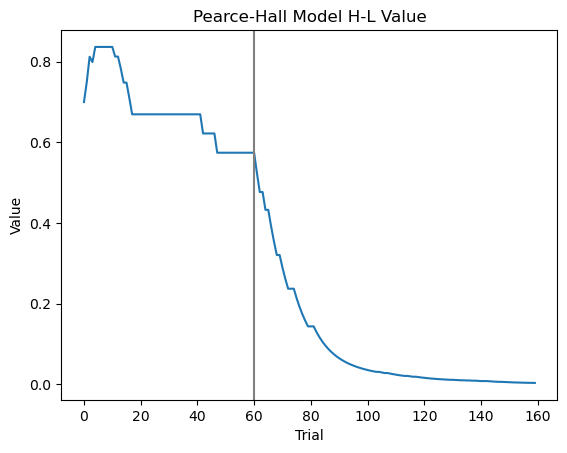

In [22]:
Qph,Dph, BICph, negLLph=fit_PH(o1_choice, o1_rew,85)
plt.plot(Qph)
plt.axvline(60, color='gray')
plt.xlabel('Trial')
plt.ylabel('Value')
plt.title('Pearce-Hall Model H-L Value')

# Run the eMack Model
as described in LePelley et al. 2004 https://psycnet.apa.org/record/2004-15295-001

In [23]:
 def mack_s(params, c, r, Q):

            # initialize variables 
            Be, Bi, theta_e, theta_i, beta=params 
            Vy=np.zeros((c.shape[0]+1)) # value of CS-Rew 
            Vn=np.zeros((c.shape[0]+1)) # value of CS-NR 
            Vnet=np.zeros((c.shape[0]+1))
            alpha=np.zeros((c.shape[0]+1)) # learning rate (variable) 
            Rs=np.zeros((c.shape[0]+1))

            if Q==15: 
                Vy[0]=0.15 
                Vn[0]=0.85 
            elif Q==85: 
                Vy[0]=0.85 
                Vn[0]=0.15 
    
            alpha[0]=0.1 
            T=c.shape[0] 
    
            for t in range(T): 
                # calculate V for trial t 
                Vnet[t]=Vy[t]-Vn[t]
                # calculate R \"effective strength of reinforcer\" 
                R=r[t]-(Vy[t]-Vn[t])
    
                # update Vy and Vn 
                if R>0: 
                    dVy=alpha[t]*Be*(1-Vy[t]+Vn[t])*np.abs(R) 
                    dVn=0 
                elif R<0: 
                    dVn=alpha[t]*Bi*(1-Vn[t]+Vy[t])*np.abs(R) 
                    dVy=0 
                else: 
                    dVy=0 
                    dVn=0 
    
                # update alpha (variable learning rate) 
                if R>0: 
                    da=-theta_e*abs(r[t]-Vy[t]+Vn[t])
                elif R<0:
                    da=-theta_i*abs(R*abs(-Vn[t]+Vy[t]))
                else:
                    da=0
  
                # update for next trial 
                Vy[t+1]=Vy[t]+dVy
                Vn[t+1]=Vn[t]+dVn

                alpha[t+1]=alpha[t]-da
                if alpha[t+1]<0.05:
                    alpha[t+1]=0.05
                if alpha[t+1]>1:
                    alpha[t+1]=1    
                
                Rs[t]=R

            return Vnet[0:160], Rs

In [24]:
def mack(params, c, r,Q):

    Be, Bi, theta_e, theta_i, beta=params 
    Vy=np.zeros((c.shape[0]+1)) # value of CS-Rew 
    Vn=np.zeros((c.shape[0]+1)) # value of CS-NR 
    Vnet=np.zeros((c.shape[0]+1))
    alpha=np.zeros((c.shape[0]+1)) # learning rate (variable) 
    Rs=np.zeros((c.shape[0]+1))
    if Q==15: 
        Vy[0]=0.15 
        Vn[0]=0.85 
        Q = [0.85,0.15]
    elif Q==85: 
        Vy[0]=0.85 
        Vn[0]=0.15 
        Q = [0.15,0.85]  
    T = len(c)
    choiceProb = np.zeros((T), dtype = float)

    for t in range(T):
        p0 = np.exp(beta*Q[0]) / (np.exp(beta*Q[0]) + np.exp(beta*Q[1]))
        p = [p0, 1-p0]
        choiceProb[t] = p[c[t]]

        # update values
        
         # calculate V for trial t 
        Vnet[t]=Vy[t]-Vn[t]
                # calculate R \"effective strength of reinforcer\" 
        R=r[t]-(Vy[t]-Vn[t])
    
         # update Vy and Vn 
        if R>0: 
            dVy=alpha[t]*Be*(1-Vy[t]+Vn[t])*np.abs(R) 
            dVn=0 
        elif R<0: 
            dVn=alpha[t]*Bi*(1-Vn[t]+Vy[t])*np.abs(R) 
            dVy=0 
        else: 
            dVy=0 
            Vn=0 
    
        # update alpha (variable learning rate) 
        if R>0: 
            da=-theta_e*abs(r[t]-Vy[t]+Vn[t])
        elif R<0:
            da=-theta_i*abs(R*abs(-Vn[t]+Vy[t]))
        else:
            da=0
  
        # update for next trial 
        Vy[t+1]=Vy[t]+dVy
        Vn[t+1]=Vn[t]+dVn
        Q[0]=Vn[t+1]
        Q[1]=Vy[t+1]

        alpha[t+1]=alpha[t]-da
        if alpha[t+1]<0.05:
            alpha[t+1]=0.05
        if alpha[t+1]>1:
            alpha[t+1]=1    
                
        Rs[t]=R
        
           
    negLL = -np.sum(np.log(choiceProb))
    
    return negLL

In [25]:
def fit_mack(c,r,Q):
    import warnings
    warnings.filterwarnings("ignore")

    res_nll = np.inf 
    for Be_guess in np.linspace(0.01,0.25,3):
        for Bi_guess in np.linspace(0.009,0.23,3):
            for theta_e_guess in np.linspace(0.01,0.1,3):
                for theta_i_guess in np.linspace(0.009,0.09,3):
                    for beta_guess in np.linspace(1,5,3):
                        if Be_guess>Bi_guess: # requirement of model
                            if theta_e_guess > theta_i_guess: # requirement of model
                                init_guess = (Be_guess, Bi_guess, theta_e_guess, theta_i_guess, beta_guess)

                          
                                result = minimize(mack, 
                                                  init_guess, 
                                                  (c, r, Q), 
                                                  bounds=((0.01,0.3),(0.009,0.3),(0.002,0.2),(0.002,0.19),(1,5)))


                                if result.fun < res_nll:
                                    res_nll = result.fun
                                    param_fits = result.x

    BIC = len(init_guess) * np.log(len(c)) + 2*res_nll

    beta_hat= param_fits[1]
    params1=[param_fits[0],param_fits[1], param_fits[2], param_fits[3], param_fits[4]]
    Q,D=mack_s(params1,c,r, 85)
    return Q, D, BIC, res_nll

Text(0.5, 1.0, 'eMack Model H-L Value')

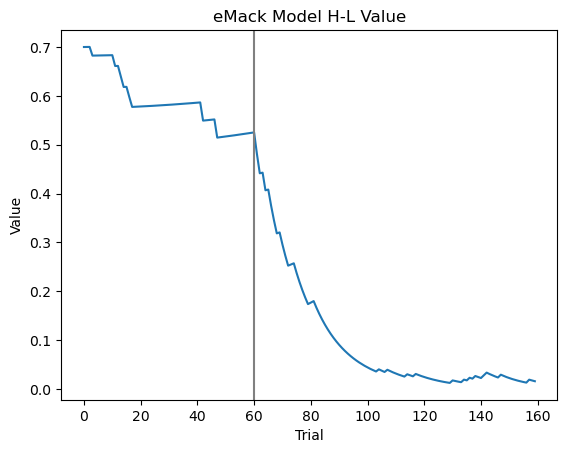

In [26]:
Qmack,Dmack, BICmack, negLLmack=fit_mack(o1_choice, o1_rew,85)
plt.plot(Qmack)
plt.axvline(60, color='gray')
plt.xlabel('Trial')
plt.ylabel('Value')
plt.title('eMack Model H-L Value')

# Summarize the Model Fitting Results

In [27]:
# unweighted fits (no parameter # penalty)
print('negLLs: mRPE', round(negLLM,3), 'RPE2a', round(negLL2a,3), 'Pearce-Hall' , round(negLLph,3), 'eMack', round(negLLmack,3) , 'RPEt-1' , round(negLLt,3), 'RPE', round(negLL,3))

negLLs: mRPE 47.658 RPE2a 59.59 Pearce-Hall 55.895 eMack 60.95 RPEt-1 54.355 RPE 62.001


In [28]:
# weighted fits (parameter # peanalty)
print('BICS: mRPE', round(BIC1M,3), 'RPE2a', round(BIC2a,3), 'Pearce-Hall' , round(BICph,3), 'eMack', round(BICmack,3) , 'RPEt-1' , round(BICt,3), 'RPE', round(BIC,3))

BICS: mRPE 115.616 RPE2a 134.406 Pearce-Hall 132.091 eMack 147.276 RPEt-1 118.86 RPE 134.152
